# Wrapped multi-year seasonal storage summary: lambda 3.5 / 3.55 / 5

This notebook compares the wrapped + trimmed multi-year runs that matter for seasonal-behavior validation:

- `3month_lambda_3.5_wrapped_1985_1988`
- `3month_lambda_3.55_wrapped_1985_1988`
- `stagel_3month_wrapped_1985_1988` (lambda 5)
- `3month_lambda_3.5_wrapped_1985_1990` for the extended "which years matter most?" view

Focus:

1. whether `lambda = 3.5` and `3.55` stay in the same stable operating region
2. whether `lambda = 5` suppresses charging and creates one-way SOC depletion
3. which retained years show the largest seasonal-storage use and strongest scarcity patterns
4. which months/seasons seasonal storage is actually useful


In [1]:
from pathlib import Path
import calendar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

OUTPUT_ROOT = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not OUTPUT_ROOT.exists():
    OUTPUT_ROOT = Path.cwd().parent / "outputs" / "historical_1980_2019"

COMMON_RUNS = {
    "3month_lambda_3.5_wrapped_1985_1988": "lambda3.5",
    "3month_lambda_3.55_wrapped_1985_1988": "lambda3.55",
    "stagel_3month_wrapped_1985_1988": "lambda5",
}

EXTENDED_RUN = {
    "3month_lambda_3.5_wrapped_1985_1990": "lambda3.5_1985_1990",
}

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Common wrapped runs:", COMMON_RUNS)
print("Extended wrapped run:", EXTENDED_RUN)


OUTPUT_ROOT: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019
Common wrapped runs: {'3month_lambda_3.5_wrapped_1985_1988': 'lambda3.5', '3month_lambda_3.55_wrapped_1985_1988': 'lambda3.55', 'stagel_3month_wrapped_1985_1988': 'lambda5'}
Extended wrapped run: {'3month_lambda_3.5_wrapped_1985_1990': 'lambda3.5_1985_1990'}


In [2]:
# --- Helpers ----------------------------------------------------------------

def _strip_tz(idx):
    if hasattr(idx, "tz") and idx.tz is not None:
        return idx.tz_convert(None)
    return idx


def _empty_tidy(value_name: str, extra_cols=None) -> pd.DataFrame:
    extra_cols = extra_cols or []
    data = {c: pd.Series(dtype=float) for c in extra_cols + [value_name]}
    data["timestamp"] = pd.to_datetime([])
    return pd.DataFrame(data)


def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(
        id_vars=meta_cols,
        value_vars=value_cols,
        var_name="timestamp",
        value_name=value_name,
    )
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def tidy_storage_path(path: Path, value_name: str) -> pd.DataFrame:
    if not path.exists():
        return _empty_tidy(value_name)
    return tidy_storage_df(pd.read_csv(path), value_name)


def tidy_bus_df(path: Path, value_name: str) -> pd.DataFrame:
    if not path.exists():
        return _empty_tidy(value_name, extra_cols=["bus_id"])
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(
        id_vars=meta_cols,
        value_vars=value_cols,
        var_name="timestamp",
        value_name=value_name,
    )
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def total_ts(df: pd.DataFrame, value_name: str) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    return df.groupby("timestamp")[value_name].sum()


def load_seasonal_soc_token(run_dir: Path, token: str) -> pd.Series:
    p = run_dir / f"storage_state_seasonal_{token}.csv"
    if not p.exists():
        return pd.Series(dtype=float)
    df = pd.read_csv(p)
    if df.empty:
        return pd.Series(dtype=float)
    cols = [c for c in df.columns if c not in ("zone",)]
    df = df[cols]
    if not df.empty and df.iloc[0, 0] == "bus_id":
        df = df.iloc[1:]
    value_cols = [c for c in df.columns if c != "bus_id"]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    soc = df[value_cols].sum(axis=0)
    soc.index = pd.to_datetime(soc.index, errors="coerce")
    soc = soc.dropna()
    soc.index = _strip_tz(soc.index)
    return soc


def safe_sum(series: pd.Series) -> float:
    return float(pd.to_numeric(series, errors="coerce").fillna(0.0).sum())


def daily_sum(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("D").sum()


def daily_mean(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("D").mean()


def monthly_sum(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("ME").sum()


def monthly_mean(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("ME").mean()


def load_manifest(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "keep_for_analysis" in df.columns:
        df["keep_for_analysis"] = pd.to_numeric(df["keep_for_analysis"], errors="coerce").fillna(0).astype(int)
        df = df[df["keep_for_analysis"] == 1].copy()
    df["seq_idx"] = pd.to_numeric(df["seq_idx"], errors="coerce").astype(int)
    df["sim_year"] = pd.to_numeric(df["sim_year"], errors="coerce").astype(int)
    if "analysis_year_idx" in df.columns:
        df["analysis_year_idx"] = pd.to_numeric(df["analysis_year_idx"], errors="coerce").fillna(0).astype(int)
    return df.sort_values("seq_idx").reset_index(drop=True)


def load_run_token(run_dir: Path, token: str) -> dict:
    return {
        "charge_base": tidy_storage_path(run_dir / f"charge_base_{token}.csv", "charge"),
        "discharge_base": tidy_storage_path(run_dir / f"discharge_base_{token}.csv", "discharge"),
        "charge_seasonal": tidy_storage_path(run_dir / f"charge_seasonal_{token}.csv", "charge"),
        "discharge_seasonal": tidy_storage_path(run_dir / f"discharge_seasonal_{token}.csv", "discharge"),
        "load_shed": tidy_bus_df(run_dir / f"load_shedding_{token}.csv", "load_shedding"),
        "wind_curt": tidy_bus_df(run_dir / f"wind_curtailment_{token}.csv", "wind_curtailment"),
        "solar_curt": tidy_bus_df(run_dir / f"solar_curtailment_{token}.csv", "solar_curtailment"),
        "soc_seasonal": load_seasonal_soc_token(run_dir, token),
    }


def compile_wrapped_run(run_name: str, label: str) -> dict:
    run_dir = OUTPUT_ROOT / run_name
    manifest = load_manifest(run_dir / "_sequence_manifest.csv")
    yearly = {}
    for _, row in manifest.iterrows():
        yearly[int(row["sim_year"])] = load_run_token(run_dir, row["token"])
    return {
        "run_name": run_name,
        "label": label,
        "run_dir": run_dir,
        "manifest": manifest,
        "yearly": yearly,
    }


def annual_record(label: str, year: int, data: dict) -> dict:
    base_ch = total_ts(data["charge_base"], "charge")
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    ls = total_ts(data["load_shed"], "load_shedding")
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")
    soc = data["soc_seasonal"]
    return {
        "run": label,
        "year": year,
        "base_charge_MWh": safe_sum(base_ch),
        "base_discharge_MWh": safe_sum(base_dis),
        "seasonal_charge_MWh": safe_sum(seas_ch),
        "seasonal_discharge_MWh": safe_sum(seas_dis),
        "load_shed_MWh": safe_sum(ls),
        "wind_curt_MWh": safe_sum(wind),
        "solar_curt_MWh": safe_sum(solar),
        "soc_start_MWh": float(soc.iloc[0]) if len(soc) else np.nan,
        "soc_end_MWh": float(soc.iloc[-1]) if len(soc) else np.nan,
        "soc_max_MWh": float(soc.max()) if len(soc) else np.nan,
        "soc_min_MWh": float(soc.min()) if len(soc) else np.nan,
    }


def activity_record(label: str, year: int, data: dict, tol: float = 1e-6) -> dict:
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    soc = data["soc_seasonal"]
    ch_d = daily_sum(seas_ch)
    dis_d = daily_sum(seas_dis)
    if seas_ch.empty:
        simult_hours = 0
    else:
        aligned = pd.concat([seas_ch.rename("charge"), seas_dis.rename("discharge")], axis=1).fillna(0.0)
        simult_hours = int(((aligned["charge"] > tol) & (aligned["discharge"] > tol)).sum())
    return {
        "run": label,
        "year": year,
        "seasonal_charge_MWh": safe_sum(seas_ch),
        "seasonal_discharge_MWh": safe_sum(seas_dis),
        "discharge_to_charge_ratio": safe_sum(seas_dis) / safe_sum(seas_ch) if safe_sum(seas_ch) > 0 else np.nan,
        "active_charge_days": int((ch_d > tol).sum()) if len(ch_d) else 0,
        "active_discharge_days": int((dis_d > tol).sum()) if len(dis_d) else 0,
        "simultaneous_hours": simult_hours,
        "soc_change_MWh": float(soc.iloc[-1] - soc.iloc[0]) if len(soc) else np.nan,
    }


def monthly_record(label: str, year: int, data: dict) -> pd.DataFrame:
    seas_ch = monthly_sum(total_ts(data["charge_seasonal"], "charge")).rename("seasonal_charge_MWh")
    seas_dis = monthly_sum(total_ts(data["discharge_seasonal"], "discharge")).rename("seasonal_discharge_MWh")
    ls = monthly_sum(total_ts(data["load_shed"], "load_shedding")).rename("load_shed_MWh")
    soc = monthly_mean(data["soc_seasonal"]).rename("soc_mean_MWh")
    df = pd.concat([seas_ch, seas_dis, ls, soc], axis=1).fillna(0.0)
    if df.empty:
        return pd.DataFrame(columns=["run", "year", "month", "month_name"] + list(df.columns))
    df = df.reset_index().rename(columns={"index": "timestamp", "timestamp": "timestamp"})
    df["run"] = label
    df["year"] = year
    df["month"] = df["timestamp"].dt.month
    df["month_name"] = df["month"].map(lambda m: calendar.month_abbr[m])
    df["net_seasonal_MWh"] = df["seasonal_charge_MWh"] - df["seasonal_discharge_MWh"]
    return df[[
        "run", "year", "month", "month_name",
        "seasonal_charge_MWh", "seasonal_discharge_MWh", "net_seasonal_MWh",
        "load_shed_MWh", "soc_mean_MWh",
    ]]


In [3]:
# --- Load the wrapped runs ---------------------------------------------------

common_runs = {name: compile_wrapped_run(name, label) for name, label in COMMON_RUNS.items()}
extended_runs = {name: compile_wrapped_run(name, label) for name, label in EXTENDED_RUN.items()}

common_year_sets = [set(run["manifest"]["sim_year"].tolist()) for run in common_runs.values()]
COMMON_YEARS = sorted(set.intersection(*common_year_sets))

print("Common comparison years:", COMMON_YEARS)
for name, bundle in common_runs.items():
    print("\n", bundle["label"])
    display(bundle["manifest"])

for name, bundle in extended_runs.items():
    print("\nExtended run manifest:", bundle["label"])
    display(bundle["manifest"])


Common comparison years: [1985, 1986, 1987, 1988]

 lambda3.5


,seq_idx,sim_year,token,prev_token,sequence_role,keep_for_analysis,analysis_year_idx
0,2,1985,seq002_y1985,seq001_y1985,analysis,1,1
1,3,1986,seq003_y1986,seq002_y1985,analysis,1,2
2,4,1987,seq004_y1987,seq003_y1986,analysis,1,3
3,5,1988,seq005_y1988,seq004_y1987,analysis,1,4



 lambda3.55


,seq_idx,sim_year,token,prev_token,sequence_role,keep_for_analysis,analysis_year_idx
0,2,1985,seq002_y1985,seq001_y1985,analysis,1,1
1,3,1986,seq003_y1986,seq002_y1985,analysis,1,2
2,4,1987,seq004_y1987,seq003_y1986,analysis,1,3
3,5,1988,seq005_y1988,seq004_y1987,analysis,1,4



 lambda5


,seq_idx,sim_year,token,prev_token,sequence_role,keep_for_analysis,analysis_year_idx
0,2,1985,seq002_y1985,seq001_y1985,analysis,1,1
1,3,1986,seq003_y1986,seq002_y1985,analysis,1,2
2,4,1987,seq004_y1987,seq003_y1986,analysis,1,3
3,5,1988,seq005_y1988,seq004_y1987,analysis,1,4



Extended run manifest: lambda3.5_1985_1990


,seq_idx,sim_year,token,prev_token,sequence_role,keep_for_analysis,analysis_year_idx
0,2,1985,seq002_y1985,seq001_y1985,analysis,1,1
1,3,1986,seq003_y1986,seq002_y1985,analysis,1,2
2,4,1987,seq004_y1987,seq003_y1986,analysis,1,3
3,5,1988,seq005_y1988,seq004_y1987,analysis,1,4
4,6,1989,seq006_y1989,seq005_y1988,analysis,1,5
5,7,1990,seq007_y1990,seq006_y1989,analysis,1,6


## A) Common-year comparison for wrapped trimmed runs (1985-1988)

Interpretation guide:

- `lambda3.5` vs `lambda3.55`: if these stay close, they are in the same stable operating region
- `lambda5`: if seasonal charging collapses while discharge still occurs, that points to inventory drawdown instead of a sustainable seasonal cycle
- focus on annual totals, SOC change, and the timing of seasonal-only charging/discharging


In [4]:
# Annual summary table for the common years
common_rows = []
for bundle in common_runs.values():
    label = bundle["label"]
    for year in COMMON_YEARS:
        common_rows.append(annual_record(label, year, bundle["yearly"][year]))

common_year_df = pd.DataFrame(common_rows)
metric_cols = [c for c in common_year_df.columns if c not in ["run", "year"]]
for c in metric_cols:
    common_year_df[c] = common_year_df[c].round(2)

print("Annual totals for retained common years:")
display(common_year_df.sort_values(["year", "run"]))

common_total_df = common_year_df.groupby("run", as_index=False)[metric_cols].sum()
for c in metric_cols:
    common_total_df[c] = common_total_df[c].round(2)

print("Totals across 1985-1988 retained years:")
display(common_total_df.sort_values("run"))


Annual totals for retained common years:


,run,year,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh,soc_start_MWh,soc_end_MWh,soc_max_MWh,soc_min_MWh
0,lambda3.5,1985,178368.65,133776.49,441628.44,433374.19,504525.63,6997674.55,10532354.64,3722627.81,3604671.85,3818375.58,3604671.85
4,lambda3.55,1985,178368.65,133776.49,439280.44,431613.19,505230.95,6966358.39,10584246.85,3722627.81,3604671.85,3816746.29,3604671.85
8,lambda5,1985,323469.34,242602.00,0.00,185267.67,637186.45,7083429.75,10686128.29,3655038.98,3441110.30,3655038.98,3441110.30
1,lambda3.5,1986,218106.37,163579.78,201067.70,202227.84,301743.74,6688794.89,10878410.90,3604671.85,3545289.00,3630724.63,3545289.00
5,lambda3.55,1986,218106.37,163579.78,199840.27,201307.26,302112.45,6756504.86,10833577.39,3604671.85,3545289.00,3629627.63,3545289.00
9,lambda5,1986,291369.53,218527.14,0.00,80542.05,362142.50,6919586.29,10889632.04,3441110.30,3348108.36,3441110.30,3348108.36
2,lambda3.5,1987,199994.83,149996.12,548223.18,454534.07,457589.33,5274834.17,9752047.92,3545289.00,3495213.47,3701631.98,3495213.47
6,lambda3.55,1987,199994.83,149996.12,545769.57,452693.86,458326.37,5236613.94,9850435.20,3545289.00,3495213.47,3701693.97,3495213.47
10,lambda5,1987,310925.52,233194.14,159116.74,239483.82,574473.06,5452036.41,9983394.14,3348108.36,3209375.41,3356400.73,3209375.41
3,lambda3.5,1988,157514.12,118135.59,601747.04,477512.21,541318.67,6518033.53,9712434.90,3495213.47,3464958.09,3623767.60,3464958.09


Totals across 1985-1988 retained years:


,run,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh,soc_start_MWh,soc_end_MWh,soc_max_MWh,soc_min_MWh
0,lambda3.5,753983.97,565487.98,1792666.36,1567648.31,1805177.37,25479337.14,40875248.36,14367802.13,14110132.41,14774499.79,14110132.41
1,lambda3.55,753983.97,565487.98,1762677.85,1545156.91,1814185.63,25426379.12,41135201.86,14367802.13,14110132.41,14771835.49,14110132.41
2,lambda5,1203100.93,902325.68,356969.74,755461.35,2236446.46,26070552.72,41516434.24,13653633.05,13090446.29,13709156.31,13090446.29


In [5]:
# Percent change relative to lambda3.5 across the common years
baseline_label = "lambda3.5"
base = common_year_df[common_year_df["run"] == baseline_label].set_index("year")
comp_rows = []
compare_metrics = [
    "seasonal_charge_MWh",
    "seasonal_discharge_MWh",
    "load_shed_MWh",
    "wind_curt_MWh",
    "solar_curt_MWh",
]

for run_label in sorted(common_year_df["run"].unique()):
    if run_label == baseline_label:
        continue
    comp = common_year_df[common_year_df["run"] == run_label].set_index("year")
    for year in COMMON_YEARS:
        row = {"run": run_label, "year": year}
        for metric in compare_metrics:
            b = base.loc[year, metric]
            v = comp.loc[year, metric]
            row[f"{metric}_pct_vs_lambda3.5"] = np.nan if b == 0 else 100.0 * (v - b) / b
        comp_rows.append(row)

common_pct_df = pd.DataFrame(comp_rows)
if not common_pct_df.empty:
    pct_cols = [c for c in common_pct_df.columns if c not in ["run", "year"]]
    for c in pct_cols:
        common_pct_df[c] = common_pct_df[c].round(2)
    print("Percent change versus lambda3.5:")
    display(common_pct_df.sort_values(["year", "run"]))


Percent change versus lambda3.5:


,run,year,seasonal_charge_MWh_pct_vs_lambda3.5,seasonal_discharge_MWh_pct_vs_lambda3.5,load_shed_MWh_pct_vs_lambda3.5,wind_curt_MWh_pct_vs_lambda3.5,solar_curt_MWh_pct_vs_lambda3.5
0,lambda3.55,1985,-0.53,-0.41,0.14,-0.45,0.49
4,lambda5,1985,-100.00,-57.25,26.29,1.23,1.46
1,lambda3.55,1986,-0.61,-0.46,0.12,1.01,-0.41
5,lambda5,1986,-100.00,-60.17,20.02,3.45,0.10
2,lambda3.55,1987,-0.45,-0.40,0.16,-0.72,1.01
6,lambda5,1987,-70.98,-47.31,25.54,3.36,2.37
3,lambda3.55,1988,-3.98,-3.76,1.33,-0.78,1.59
7,lambda5,1988,-67.12,-47.61,22.41,1.50,2.52


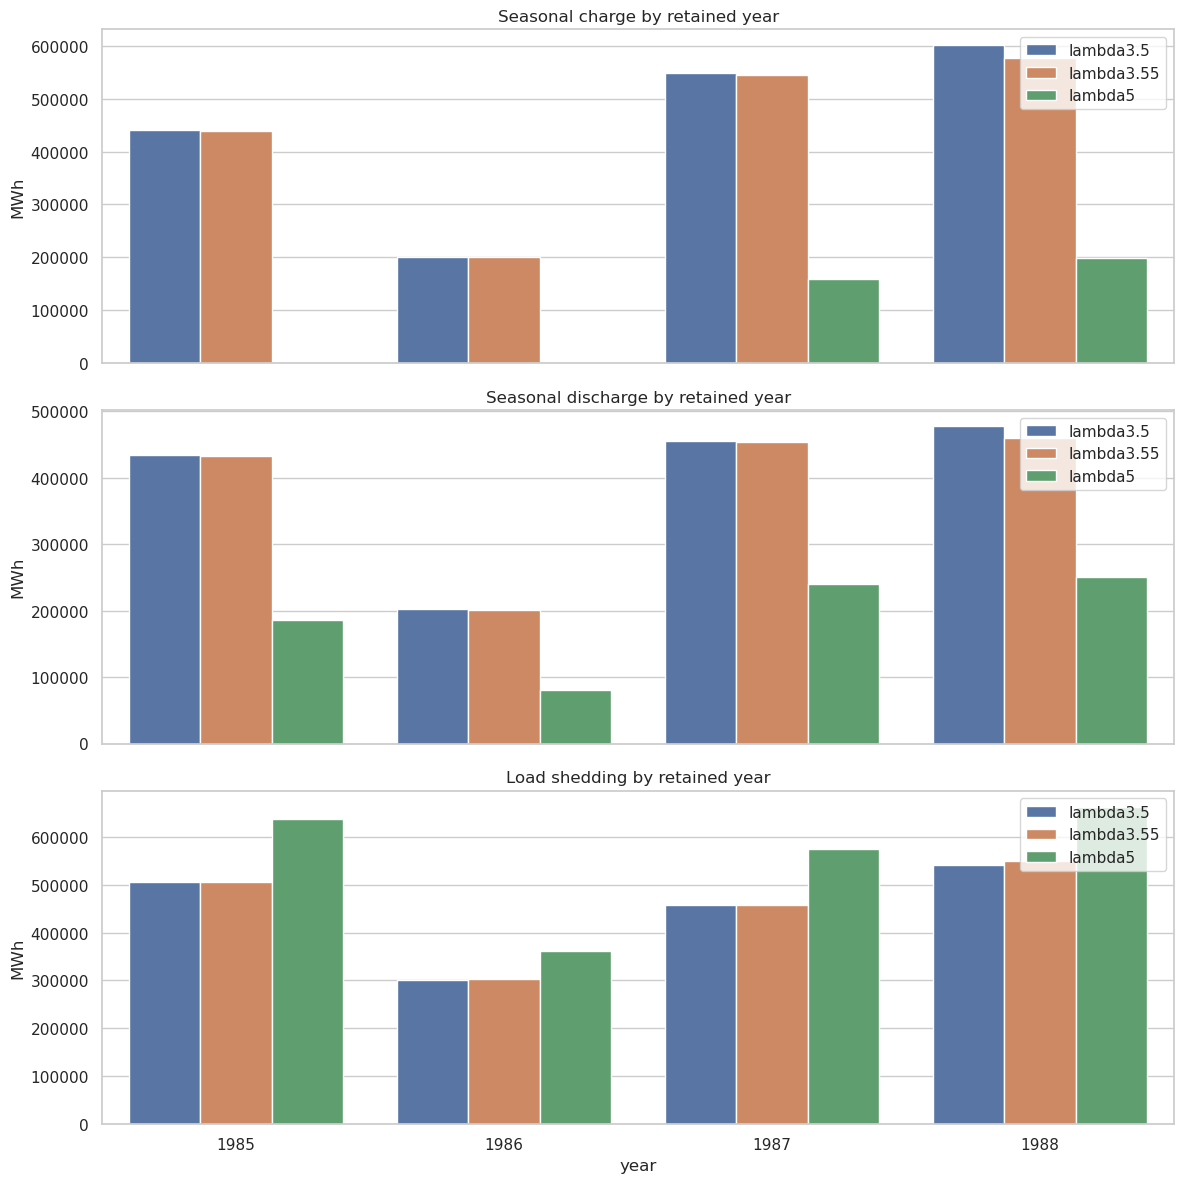

In [6]:
# Grouped bar charts for the common-year comparison
plot_metrics = [
    ("seasonal_charge_MWh", "Seasonal charge"),
    ("seasonal_discharge_MWh", "Seasonal discharge"),
    ("load_shed_MWh", "Load shedding"),
]

fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(12, 12), sharex=True)
for ax, (metric, title) in zip(axes, plot_metrics):
    sns.barplot(data=common_year_df, x="year", y=metric, hue="run", ax=ax)
    ax.set_title(f"{title} by retained year")
    ax.set_ylabel("MWh")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## B) SOC and seasonal-only operating pattern in the common years

These plots are the direct check for:

- whether `lambda3.5` and `3.55` are practically the same regime
- whether `lambda5` is suppressing charging
- whether the SOC pattern looks like a renewable-surplus build followed by scarcity discharge


In [7]:
# SOC inventory table and seasonal activity table
activity_rows = []
for bundle in common_runs.values():
    label = bundle["label"]
    for year in COMMON_YEARS:
        activity_rows.append(activity_record(label, year, bundle["yearly"][year]))

activity_df = pd.DataFrame(activity_rows)
for c in [c for c in activity_df.columns if c not in ["run", "year"]]:
    activity_df[c] = activity_df[c].round(2)

inventory_cols = ["run", "year", "soc_start_MWh", "soc_end_MWh", "soc_min_MWh", "soc_max_MWh"]
inventory_df = common_year_df[inventory_cols].copy()
inventory_df["soc_change_MWh"] = (inventory_df["soc_end_MWh"] - inventory_df["soc_start_MWh"]).round(2)

print("SOC inventory by year:")
display(inventory_df.sort_values(["year", "run"]))

print("Seasonal activity diagnostics by year:")
display(activity_df.sort_values(["year", "run"]))


SOC inventory by year:


,run,year,soc_start_MWh,soc_end_MWh,soc_min_MWh,soc_max_MWh,soc_change_MWh
0,lambda3.5,1985,3722627.81,3604671.85,3604671.85,3818375.58,-117955.96
4,lambda3.55,1985,3722627.81,3604671.85,3604671.85,3816746.29,-117955.96
8,lambda5,1985,3655038.98,3441110.30,3441110.30,3655038.98,-213928.68
1,lambda3.5,1986,3604671.85,3545289.00,3545289.00,3630724.63,-59382.85
5,lambda3.55,1986,3604671.85,3545289.00,3545289.00,3629627.63,-59382.85
9,lambda5,1986,3441110.30,3348108.36,3348108.36,3441110.30,-93001.94
2,lambda3.5,1987,3545289.00,3495213.47,3495213.47,3701631.98,-50075.53
6,lambda3.55,1987,3545289.00,3495213.47,3495213.47,3701693.97,-50075.53
10,lambda5,1987,3348108.36,3209375.41,3209375.41,3356400.73,-138732.95
3,lambda3.5,1988,3495213.47,3464958.09,3464958.09,3623767.60,-30255.38


Seasonal activity diagnostics by year:


,run,year,seasonal_charge_MWh,seasonal_discharge_MWh,discharge_to_charge_ratio,active_charge_days,active_discharge_days,simultaneous_hours,soc_change_MWh
0,lambda3.5,1985,441628.44,433374.19,0.98,179,71,4,-117955.96
4,lambda3.55,1985,439280.44,431613.19,0.98,206,69,8,-117955.96
8,lambda5,1985,0.00,185267.67,NaN,0,30,0,-213928.68
1,lambda3.5,1986,201067.70,202227.84,1.01,109,53,1,-59382.85
5,lambda3.55,1986,199840.27,201307.26,1.01,136,52,1,-59382.85
9,lambda5,1986,0.00,80542.05,NaN,0,17,0,-93001.95
2,lambda3.5,1987,548223.18,454534.07,0.83,181,58,0,-50075.53
6,lambda3.55,1987,545769.57,452693.86,0.83,180,57,1,-50075.53
10,lambda5,1987,159116.74,239483.82,1.51,105,31,0,-138732.95
3,lambda3.5,1988,601747.04,477512.21,0.79,213,65,0,-30255.37


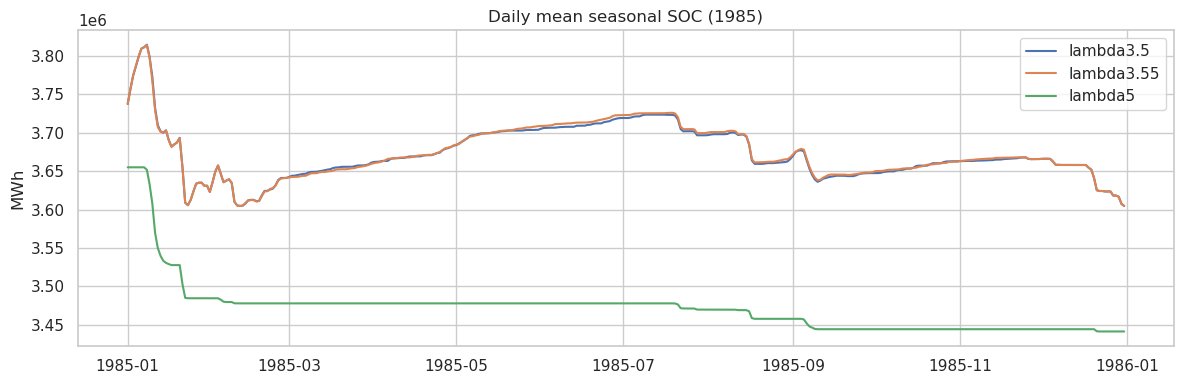

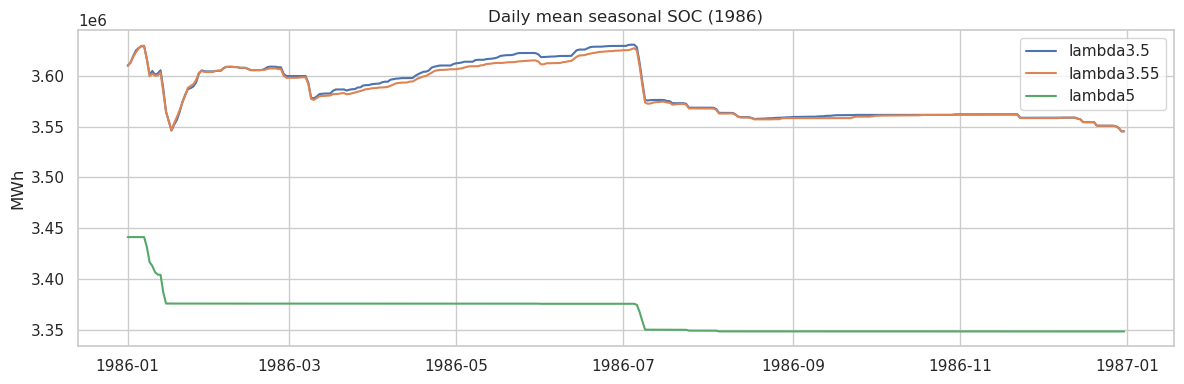

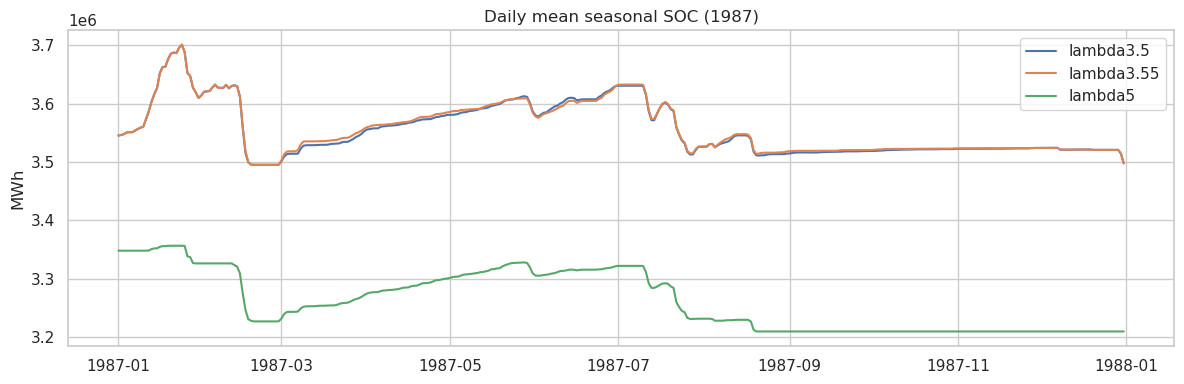

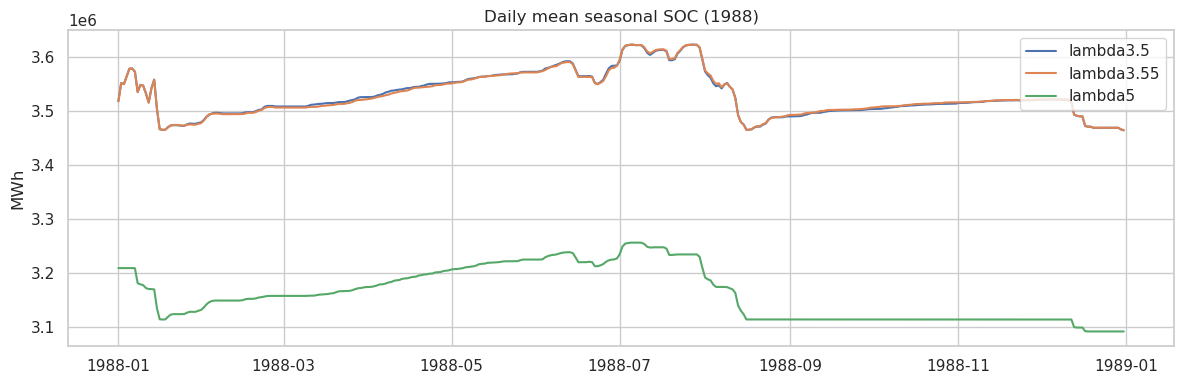

In [8]:
# Overlay daily mean SOC by year across lambda settings
for year in COMMON_YEARS:
    fig, ax = plt.subplots(figsize=(12, 4))
    for bundle in common_runs.values():
        label = bundle["label"]
        soc = daily_mean(bundle["yearly"][year]["soc_seasonal"])
        if soc.empty:
            continue
        ax.plot(soc.index, soc.values, label=label)
    ax.set_title(f"Daily mean seasonal SOC ({year})")
    ax.set_ylabel("MWh")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


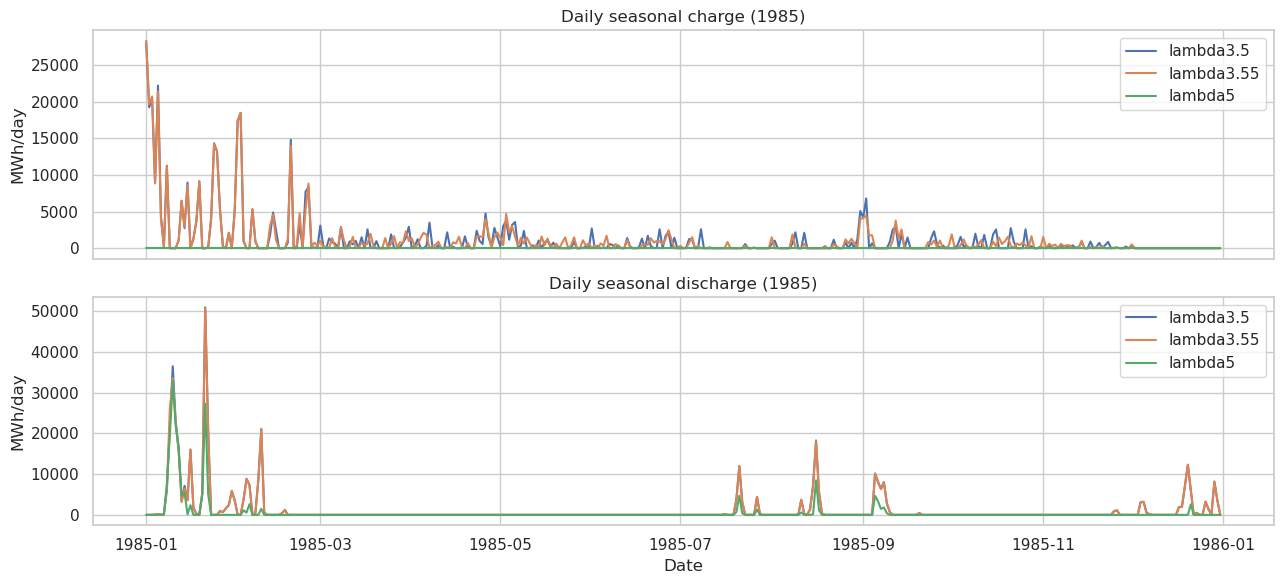

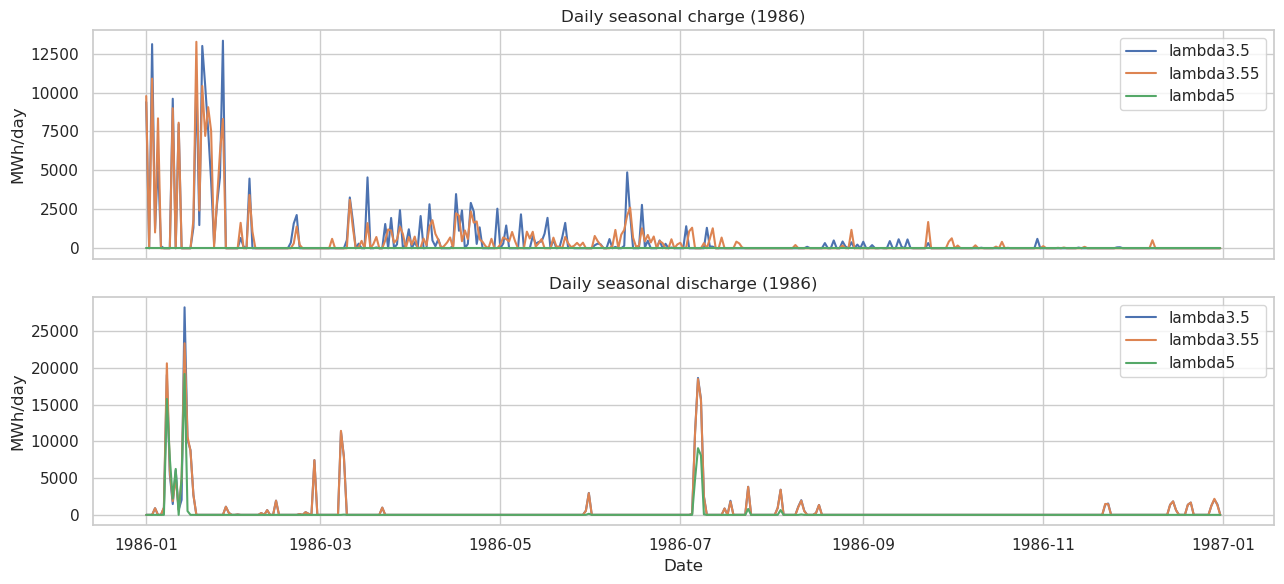

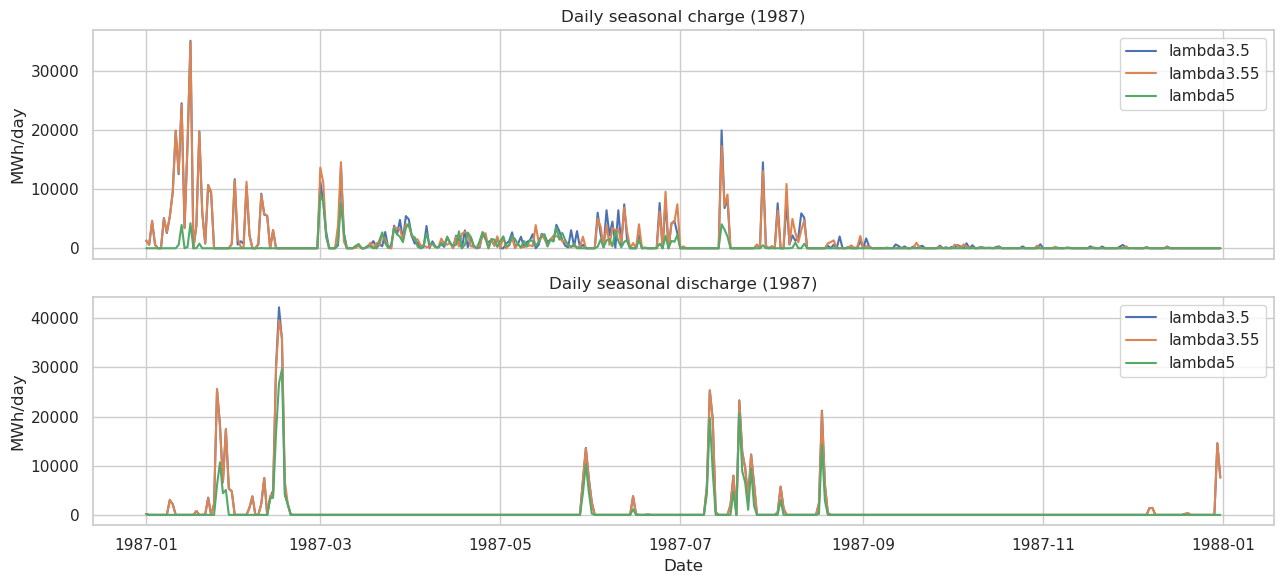

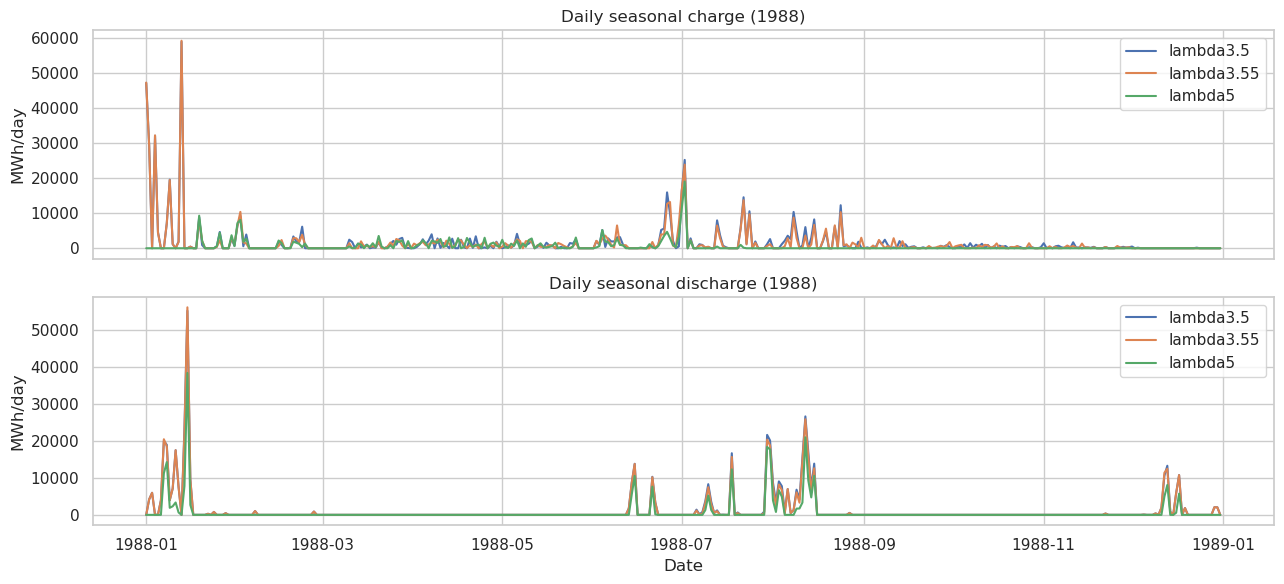

In [9]:
# Overlay seasonal-only charge/discharge by year across lambda settings
for year in COMMON_YEARS:
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    for bundle in common_runs.values():
        label = bundle["label"]
        seas_ch = daily_sum(total_ts(bundle["yearly"][year]["charge_seasonal"], "charge"))
        seas_dis = daily_sum(total_ts(bundle["yearly"][year]["discharge_seasonal"], "discharge"))
        if not seas_ch.empty:
            axes[0].plot(seas_ch.index, seas_ch.values, label=label)
        if not seas_dis.empty:
            axes[1].plot(seas_dis.index, seas_dis.values, label=label)
    axes[0].set_title(f"Daily seasonal charge ({year})")
    axes[0].set_ylabel("MWh/day")
    axes[1].set_title(f"Daily seasonal discharge ({year})")
    axes[1].set_ylabel("MWh/day")
    axes[1].set_xlabel("Date")
    axes[0].legend(loc="upper right")
    axes[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


## C) Lambda 5 suppression diagnostic

If `lambda5` is in the "too expensive to use sustainably" regime, the expected pattern is:

- seasonal charge much lower than `lambda3.5` / `3.55`
- seasonal discharge still nonzero in some years
- SOC drifting downward across retained years
- higher load shedding because seasonal storage is no longer building inventory


In [10]:
# Compact lambda-5 diagnostic versus lambda3.5 and lambda3.55
diag_cols = [
    "run", "year",
    "seasonal_charge_MWh", "seasonal_discharge_MWh",
    "discharge_to_charge_ratio", "active_charge_days", "active_discharge_days",
    "soc_change_MWh",
]
lambda5_diag = activity_df[diag_cols].sort_values(["year", "run"]).copy()
display(lambda5_diag)

totals_compare = common_total_df[[
    "run", "seasonal_charge_MWh", "seasonal_discharge_MWh", "load_shed_MWh"
]].copy()
display(totals_compare.sort_values("run"))


,run,year,seasonal_charge_MWh,seasonal_discharge_MWh,discharge_to_charge_ratio,active_charge_days,active_discharge_days,soc_change_MWh
0,lambda3.5,1985,441628.44,433374.19,0.98,179,71,-117955.96
4,lambda3.55,1985,439280.44,431613.19,0.98,206,69,-117955.96
8,lambda5,1985,0.00,185267.67,NaN,0,30,-213928.68
1,lambda3.5,1986,201067.70,202227.84,1.01,109,53,-59382.85
5,lambda3.55,1986,199840.27,201307.26,1.01,136,52,-59382.85
9,lambda5,1986,0.00,80542.05,NaN,0,17,-93001.95
2,lambda3.5,1987,548223.18,454534.07,0.83,181,58,-50075.53
6,lambda3.55,1987,545769.57,452693.86,0.83,180,57,-50075.53
10,lambda5,1987,159116.74,239483.82,1.51,105,31,-138732.95
3,lambda3.5,1988,601747.04,477512.21,0.79,213,65,-30255.37


,run,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh
0,lambda3.5,1792666.36,1567648.31,1805177.37
1,lambda3.55,1762677.85,1545156.91,1814185.63
2,lambda5,356969.74,755461.35,2236446.46


## D) Which retained years matter most? Lambda 3.5 wrapped 1985-1990

This section uses the longer `1985-1990` wrapped trimmed run to rank which years seasonal storage is used most heavily, when discharge occurs, and what seasonal pattern each high-value year shows.


In [11]:
# Extended-run annual totals and ranking
extended_bundle = list(extended_runs.values())[0]
extended_label = extended_bundle["label"]
EXTENDED_YEARS = extended_bundle["manifest"]["sim_year"].tolist()

extended_rows = []
for year in EXTENDED_YEARS:
    extended_rows.append(annual_record(extended_label, year, extended_bundle["yearly"][year]))

extended_year_df = pd.DataFrame(extended_rows)
for c in [c for c in extended_year_df.columns if c not in ["run", "year"]]:
    extended_year_df[c] = extended_year_df[c].round(2)

print("Annual totals for lambda3.5 wrapped 1985-1990 (trimmed retained years):")
display(extended_year_df.sort_values("year"))

rank_df = extended_year_df[[
    "year", "seasonal_charge_MWh", "seasonal_discharge_MWh", "load_shed_MWh",
    "wind_curt_MWh", "solar_curt_MWh"
]].copy()
rank_df["discharge_rank"] = rank_df["seasonal_discharge_MWh"].rank(ascending=False, method="dense").astype(int)
rank_df["load_shed_rank"] = rank_df["load_shed_MWh"].rank(ascending=False, method="dense").astype(int)
rank_df = rank_df.sort_values(["discharge_rank", "year"]).reset_index(drop=True)

print("Year ranking by seasonal discharge and load shedding:")
display(rank_df)


Annual totals for lambda3.5 wrapped 1985-1990 (trimmed retained years):


,run,year,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh,soc_start_MWh,soc_end_MWh,soc_max_MWh,soc_min_MWh
0,lambda3.5_1985_1990,1985,178368.65,133776.49,441628.44,433374.19,504525.63,6997674.55,10532354.64,3722627.81,3604671.85,3818375.58,3604671.85
1,lambda3.5_1985_1990,1986,218106.37,163579.78,201067.70,202227.84,301743.74,6688794.89,10878410.90,3604671.85,3545289.00,3630724.63,3545289.00
2,lambda3.5_1985_1990,1987,199994.83,149996.12,548223.18,454534.07,457589.33,5274834.17,9752047.92,3545289.00,3495213.47,3701631.98,3495213.47
3,lambda3.5_1985_1990,1988,157514.12,118135.59,601747.04,477512.21,541318.67,6518033.53,9712434.90,3495213.47,3464958.09,3623767.60,3464958.09
4,lambda3.5_1985_1990,1989,246789.58,185092.18,556835.06,438498.56,461661.00,4842686.17,8938670.57,3464958.09,3440856.87,3622783.15,3440856.87
5,lambda3.5_1985_1990,1990,30841.22,23130.92,137047.14,102785.35,397738.83,6476755.85,9753731.59,3440856.87,3440856.87,3520419.21,3440856.87


Year ranking by seasonal discharge and load shedding:


,year,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh,discharge_rank,load_shed_rank
0,1988,601747.04,477512.21,541318.67,6518033.53,9712434.90,1,1
1,1987,548223.18,454534.07,457589.33,5274834.17,9752047.92,2,4
2,1989,556835.06,438498.56,461661.00,4842686.17,8938670.57,3,3
3,1985,441628.44,433374.19,504525.63,6997674.55,10532354.64,4,2
4,1986,201067.70,202227.84,301743.74,6688794.89,10878410.90,5,6
5,1990,137047.14,102785.35,397738.83,6476755.85,9753731.59,6,5


In [12]:
# Year characteristics: when does charging/discharging happen?
char_rows = []
for year in EXTENDED_YEARS:
    data = extended_bundle["yearly"][year]
    seas_ch_month = monthly_sum(total_ts(data["charge_seasonal"], "charge"))
    seas_dis_month = monthly_sum(total_ts(data["discharge_seasonal"], "discharge"))
    seas_ch_day = daily_sum(total_ts(data["charge_seasonal"], "charge"))
    seas_dis_day = daily_sum(total_ts(data["discharge_seasonal"], "discharge"))
    ls_month = monthly_sum(total_ts(data["load_shed"], "load_shedding"))

    peak_charge_month = int(seas_ch_month.idxmax().month) if len(seas_ch_month) else np.nan
    peak_discharge_month = int(seas_dis_month.idxmax().month) if len(seas_dis_month) else np.nan
    peak_ls_month = int(ls_month.idxmax().month) if len(ls_month) else np.nan

    char_rows.append({
        "year": year,
        "seasonal_charge_MWh": safe_sum(total_ts(data["charge_seasonal"], "charge")),
        "seasonal_discharge_MWh": safe_sum(total_ts(data["discharge_seasonal"], "discharge")),
        "charge_days": int((seas_ch_day > 1e-6).sum()) if len(seas_ch_day) else 0,
        "discharge_days": int((seas_dis_day > 1e-6).sum()) if len(seas_dis_day) else 0,
        "peak_charge_month": calendar.month_abbr[int(peak_charge_month)] if pd.notna(peak_charge_month) else None,
        "peak_discharge_month": calendar.month_abbr[int(peak_discharge_month)] if pd.notna(peak_discharge_month) else None,
        "peak_load_shed_month": calendar.month_abbr[int(peak_ls_month)] if pd.notna(peak_ls_month) else None,
        "discharge_to_charge_ratio": safe_sum(total_ts(data["discharge_seasonal"], "discharge")) / safe_sum(total_ts(data["charge_seasonal"], "charge")) if safe_sum(total_ts(data["charge_seasonal"], "charge")) > 0 else np.nan,
    })

char_df = pd.DataFrame(char_rows)
for c in [c for c in char_df.columns if c not in ["year", "peak_charge_month", "peak_discharge_month", "peak_load_shed_month"]]:
    char_df[c] = char_df[c].round(2)
display(char_df.sort_values("year"))


,year,seasonal_charge_MWh,seasonal_discharge_MWh,charge_days,discharge_days,peak_charge_month,peak_discharge_month,peak_load_shed_month,discharge_to_charge_ratio
0,1985,441628.44,433374.19,179,71,Jan,Jan,Aug,0.98
1,1986,201067.70,202227.84,109,53,Jan,Jan,Jul,1.01
2,1987,548223.18,454534.07,181,58,Jan,Feb,Jul,0.83
3,1988,601747.04,477512.21,213,65,Jan,Jan,Aug,0.79
4,1989,556835.06,438498.56,199,72,Dec,Dec,Aug,0.79
5,1990,137047.14,102785.35,134,35,Jan,Aug,Aug,0.75


Monthly seasonal/storage summary:


,run,year,month,month_name,seasonal_charge_MWh,seasonal_discharge_MWh,net_seasonal_MWh,load_shed_MWh,soc_mean_MWh
0,lambda3.5_1985_1990,1985,1,Jan,192550.598969,228136.076066,-35585.477096,42933.257832,3.701403e+06
1,lambda3.5_1985_1990,1985,2,Feb,87327.802492,52269.312226,35058.490267,19982.231611,3.626537e+06
2,lambda3.5_1985_1990,1985,3,Mar,24007.190467,0.000000,24007.190467,0.000000,3.652121e+06
3,lambda3.5_1985_1990,1985,4,Apr,25097.199859,0.000000,25097.199859,0.000000,3.669886e+06
4,lambda3.5_1985_1990,1985,5,May,23333.907337,0.000000,23333.907337,2871.022516,3.699162e+06
...,...,...,...,...,...,...,...,...,...
67,lambda3.5_1985_1990,1990,8,Aug,2561.935820,45699.068879,-43137.133060,155645.567485,3.469311e+06
68,lambda3.5_1985_1990,1990,9,Sep,686.506279,219.699850,466.806429,23862.393000,3.447144e+06
69,lambda3.5_1985_1990,1990,10,Oct,2520.046433,968.065856,1551.980577,12873.763741,3.447397e+06
70,lambda3.5_1985_1990,1990,11,Nov,810.390028,0.000000,810.390028,1305.334512,3.448761e+06


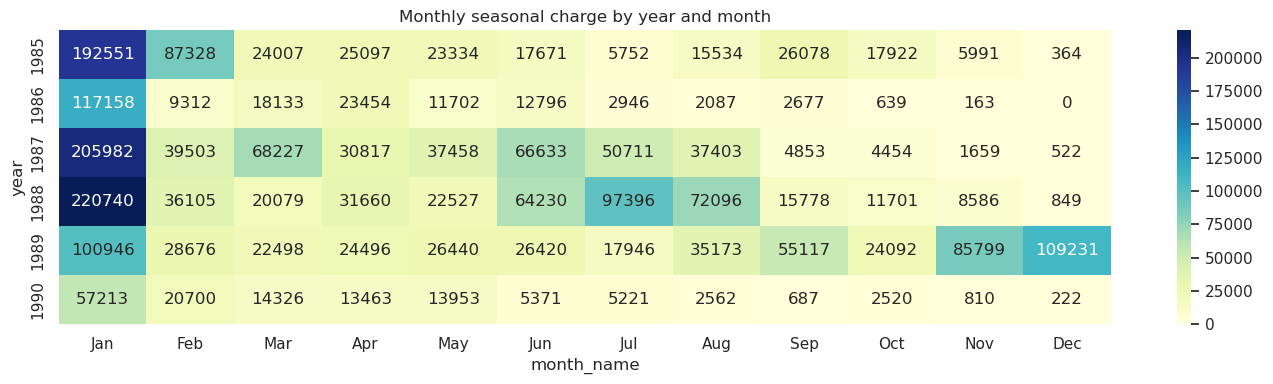

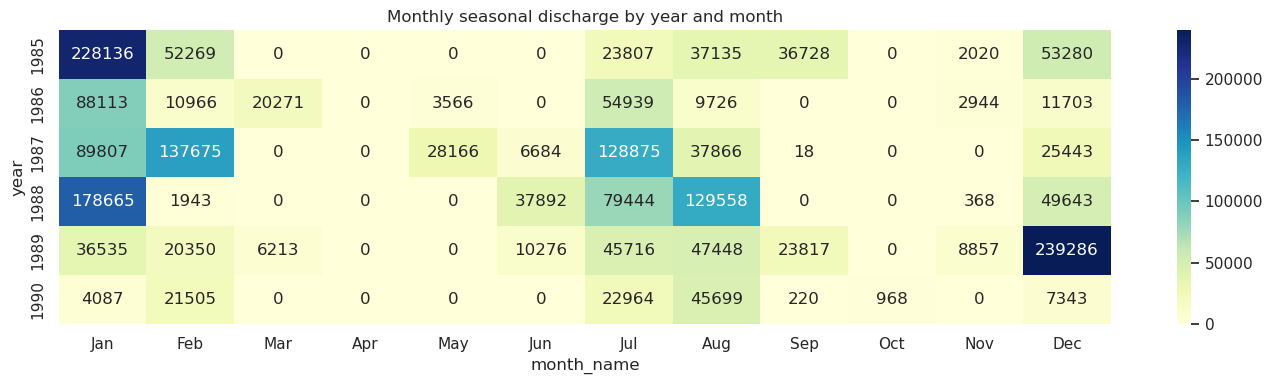

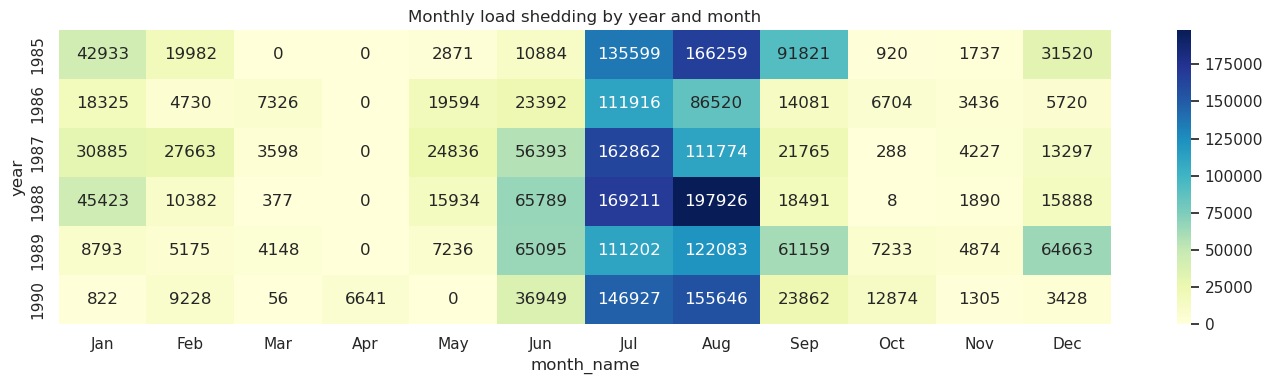

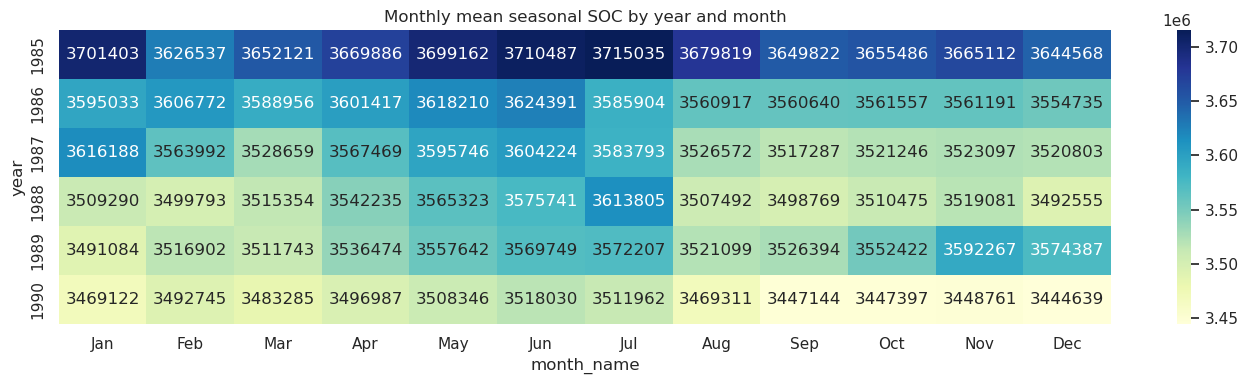

In [13]:
# Monthly heatmaps for the extended lambda3.5 run
monthly_frames = [monthly_record(extended_label, year, extended_bundle["yearly"][year]) for year in EXTENDED_YEARS]
monthly_df = pd.concat(monthly_frames, ignore_index=True)

print("Monthly seasonal/storage summary:")
display(monthly_df.sort_values(["year", "month"]))

for metric, title in [
    ("seasonal_charge_MWh", "Monthly seasonal charge"),
    ("seasonal_discharge_MWh", "Monthly seasonal discharge"),
    ("load_shed_MWh", "Monthly load shedding"),
    ("soc_mean_MWh", "Monthly mean seasonal SOC"),
]:
    pivot = monthly_df.pivot(index="year", columns="month_name", values=metric)
    pivot = pivot[[calendar.month_abbr[m] for m in range(1, 13) if calendar.month_abbr[m] in pivot.columns]]
    plt.figure(figsize=(14, 4))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title(f"{title} by year and month")
    plt.tight_layout()
    plt.show()


Top years by seasonal discharge (with load-shed tie-break): [1988, 1987, 1989, 1985]


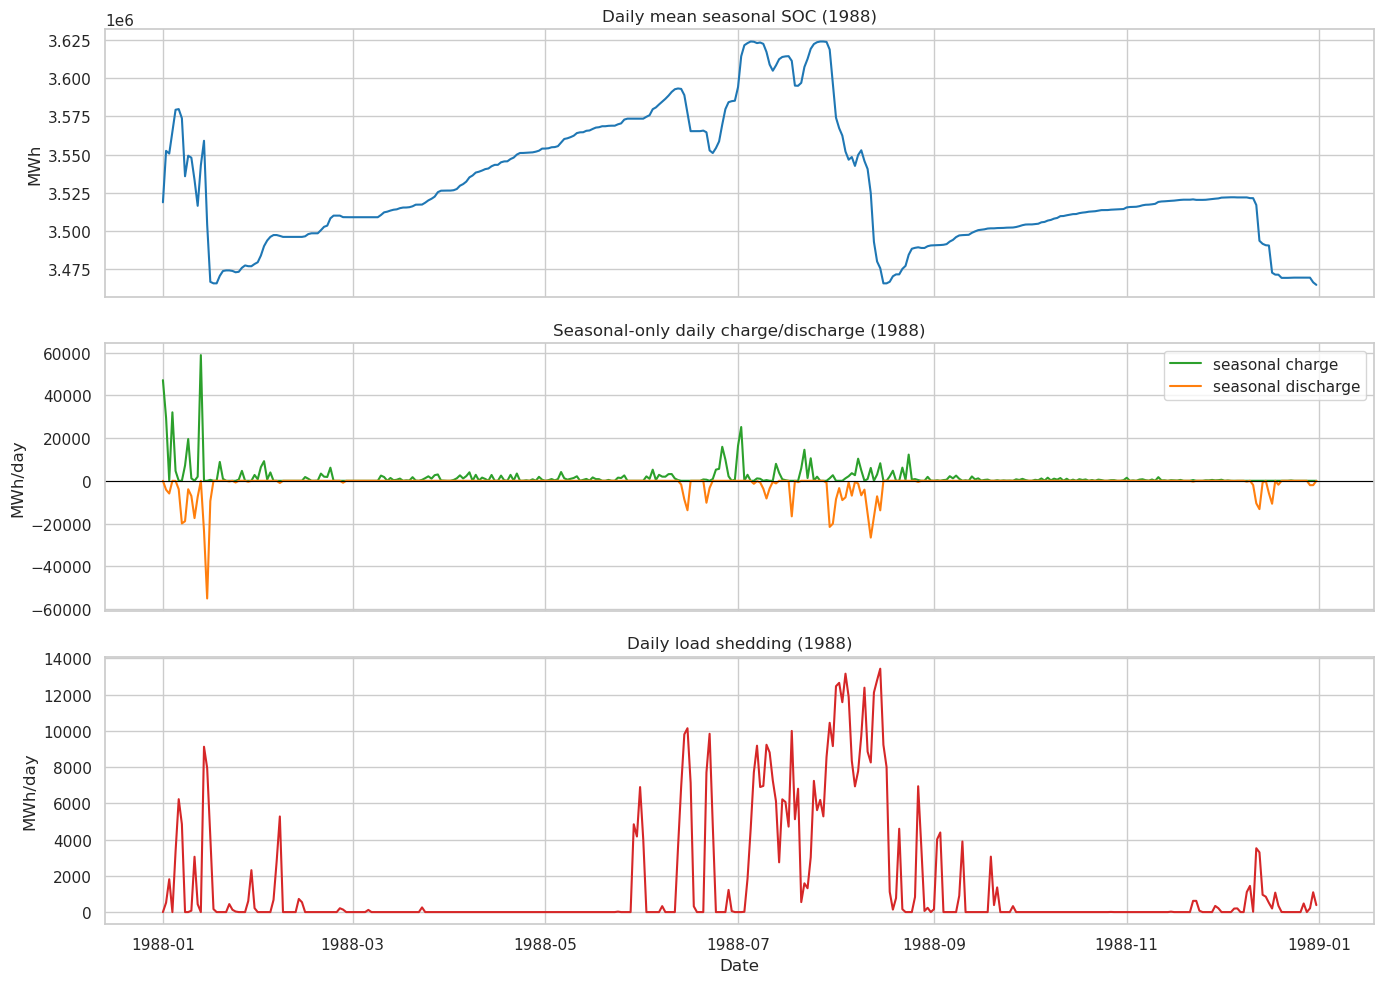

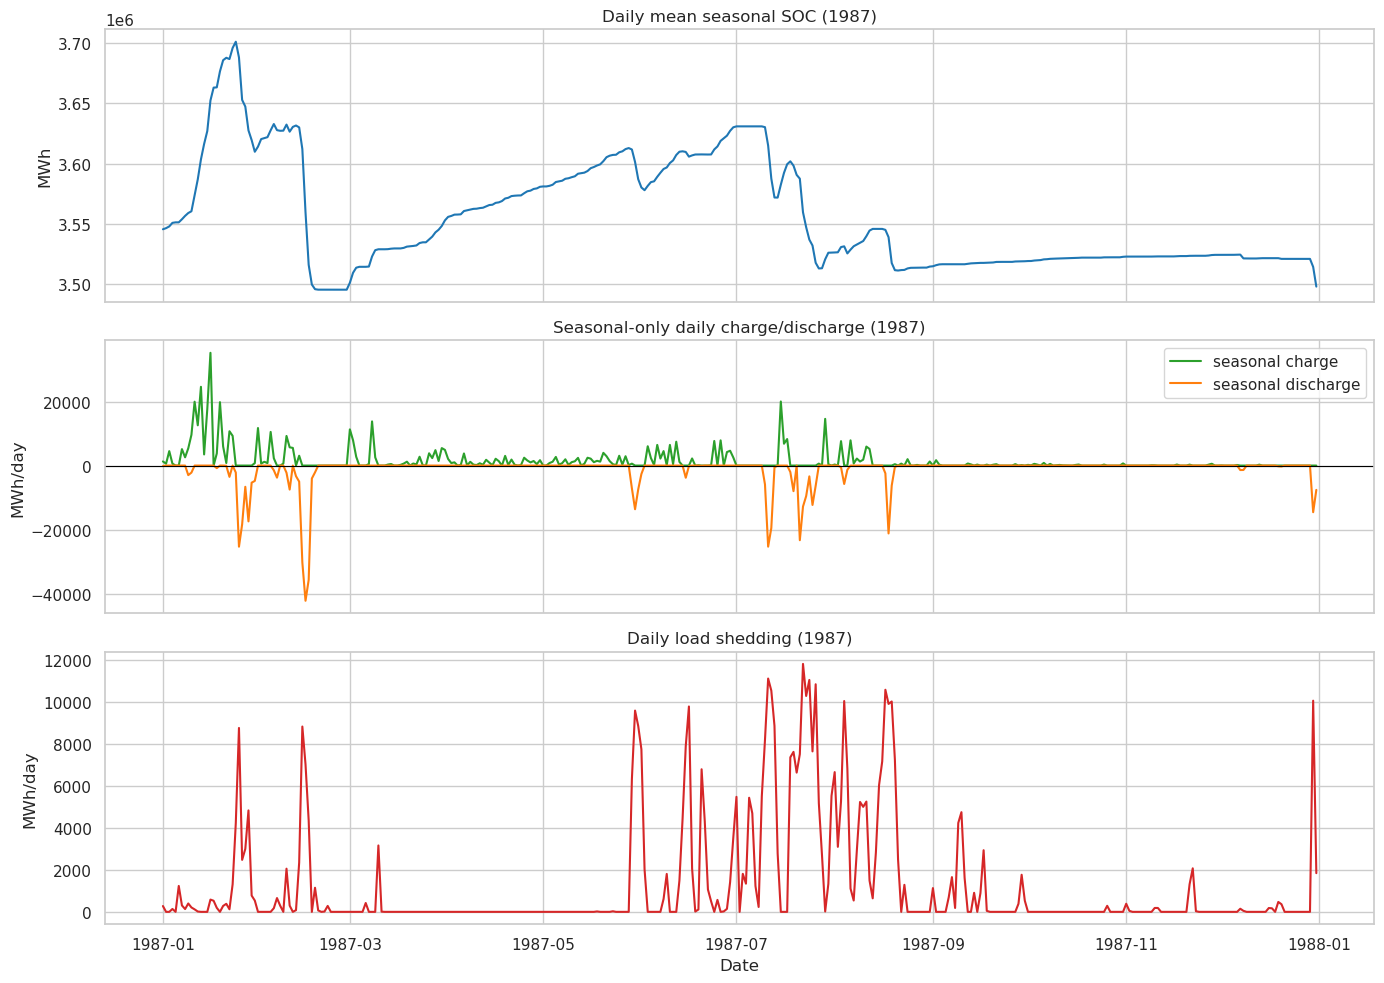

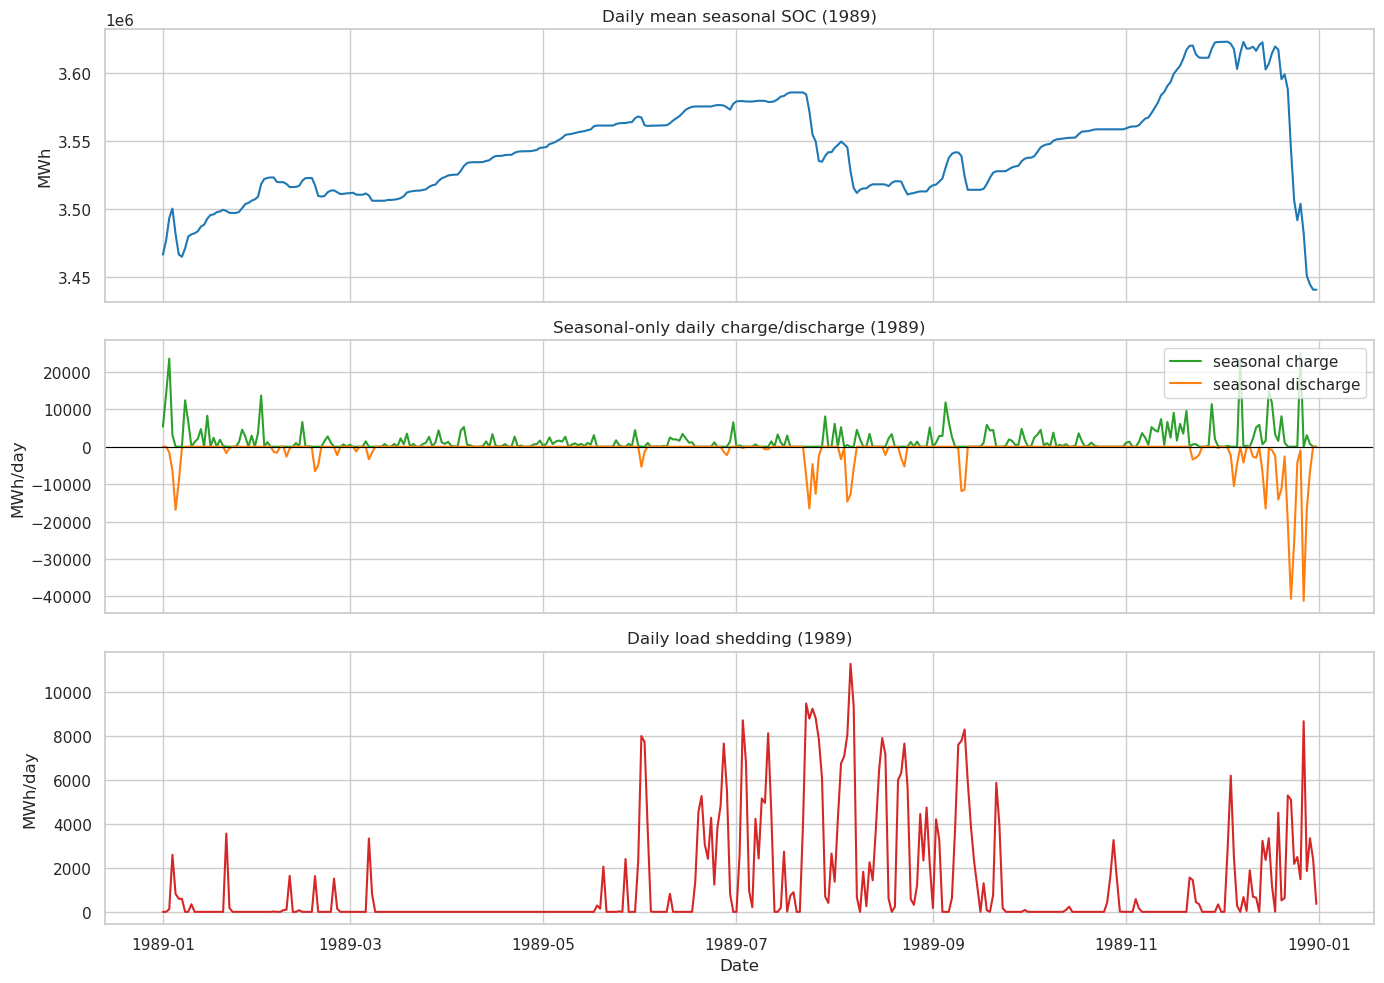

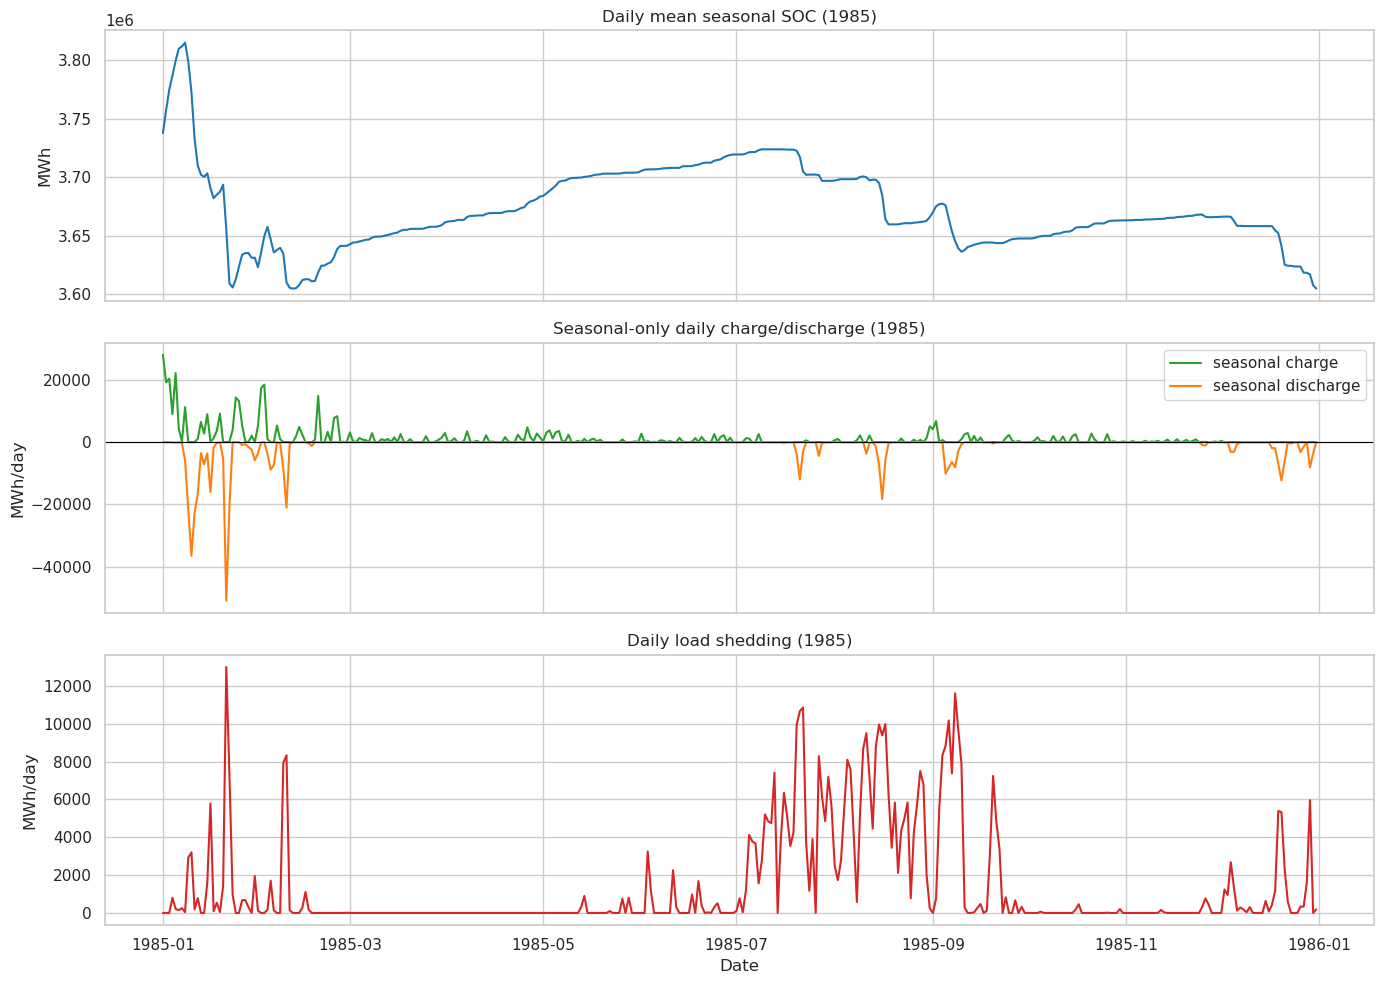

In [14]:
# Detailed daily traces for the most seasonally valuable years
top_years = (
    extended_year_df.sort_values(["seasonal_discharge_MWh", "load_shed_MWh"], ascending=[False, False])["year"]
    .head(4)
    .tolist()
)

print("Top years by seasonal discharge (with load-shed tie-break):", top_years)

for year in top_years:
    data = extended_bundle["yearly"][year]
    seas_ch = daily_sum(total_ts(data["charge_seasonal"], "charge"))
    seas_dis = daily_sum(total_ts(data["discharge_seasonal"], "discharge"))
    soc = daily_mean(data["soc_seasonal"])
    ls = daily_sum(total_ts(data["load_shed"], "load_shedding"))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(soc.index, soc.values, color="tab:blue")
    axes[0].set_title(f"Daily mean seasonal SOC ({year})")
    axes[0].set_ylabel("MWh")

    axes[1].plot(seas_ch.index, seas_ch.values, label="seasonal charge", color="tab:green")
    axes[1].plot(seas_dis.index, -seas_dis.values, label="seasonal discharge", color="tab:orange")
    axes[1].axhline(0.0, color="black", linewidth=0.8)
    axes[1].set_title(f"Seasonal-only daily charge/discharge ({year})")
    axes[1].set_ylabel("MWh/day")
    axes[1].legend(loc="upper right")

    axes[2].plot(ls.index, ls.values, color="tab:red")
    axes[2].set_title(f"Daily load shedding ({year})")
    axes[2].set_ylabel("MWh/day")
    axes[2].set_xlabel("Date")

    plt.tight_layout()
    plt.show()


## E) Reading the notebook

Use the outputs in this order:

1. check whether `lambda3.5` and `3.55` are nearly identical in the annual common-year tables
2. check whether `lambda5` has sharply lower seasonal charge and more negative SOC change
3. use the extended `1985-1990` ranking table to identify the most seasonally valuable years
4. use the monthly heatmaps and top-year daily traces to explain *why* those years matter

This keeps the evidence chain aligned with the wrapped + trimmed design:

- no reliance on the repeated first/last boundary years
- cross-year SOC carryover preserved
- free initial-SOC effects reduced relative to a one-year test
